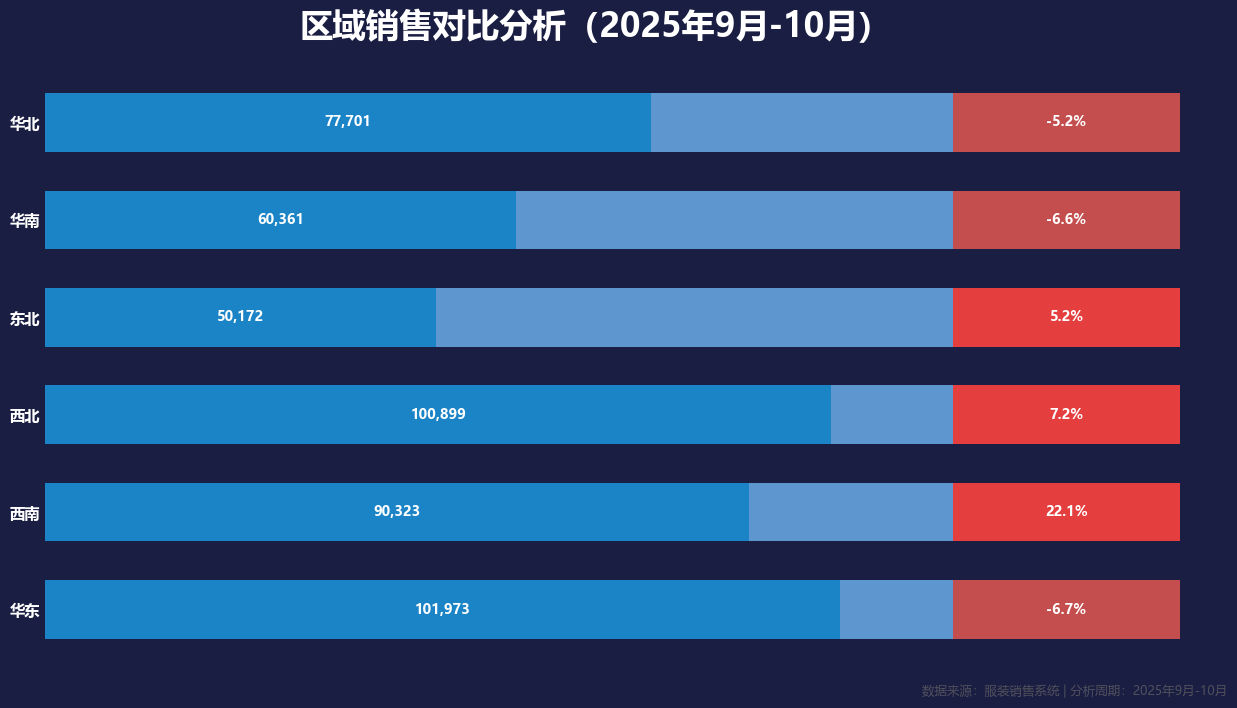

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 区域划分映射
REGION_MAP = {
    "华南": ["广东省", "广西壮族自治区", "海南省", "福建省"],
    "华北": ["北京市", "天津市", "河北省", "山西省", "内蒙古自治区"],
    "东北": ["辽宁省", "吉林省", "黑龙江省"],
    "西北": ["陕西省", "甘肃省", "青海省", "宁夏回族自治区", "新疆维吾尔自治区"],
    "华东": ["上海市", "江苏省", "浙江省", "安徽省", "山东省", "江西省"],
    "西南": ["重庆市", "四川省", "贵州省", "云南省", "西藏自治区"]
}

def get_region(province: str) -> str:
    """根据省份确定所属区域"""
    for region, provinces in REGION_MAP.items():
        if province in provinces:
            return region
    return "其他"

# 读取生成的数据集
try:
    # 严格读取CSV文件
    orders = pd.read_csv('../../数据生成/erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要的列是否存在
    required_columns = ['下单时间', '省份', '商品金额']
    for col in required_columns:
        if col not in orders.columns:
            raise ValueError(f"订单数据中缺少必要列: {col}")
    
    # 转换日期列
    orders['下单时间'] = pd.to_datetime(orders['下单时间'], errors='coerce')
    
    # 过滤无效日期
    orders = orders[orders['下单时间'].notnull()]
    
    # 添加区域列
    orders['区域'] = orders['省份'].apply(get_region)
    
    # 过滤掉"其他"区域
    orders = orders[orders['区域'] != "其他"]
    
    # 提取年份和月份
    orders['年份'] = orders['下单时间'].dt.year
    orders['月份'] = orders['下单时间'].dt.month
    
    # 确保只有2025年9月和10月的数据
    orders = orders[(orders['年份'] == 2025) & (orders['月份'].isin([9, 10]))]
    
    if orders.empty:
        raise ValueError("没有2025年9月或10月的订单数据")
    
    # 创建月份标识列
    orders['月份标识'] = orders.apply(
        lambda x: f"2025年{x['月份']}月", 
        axis=1
    )
    
    # 按区域和月份标识汇总销售数据
    region_sales = orders.groupby(['区域', '月份标识'])['商品金额'].sum().reset_index()
    
    # 转换为宽格式
    pivot_data = region_sales.pivot(index='区域', columns='月份标识', values='商品金额').reset_index()
    
    # 确保两个月份都有数据
    required_months = ['2025年9月', '2025年10月']
    for month in required_months:
        if month not in pivot_data.columns:
            pivot_data[month] = 0
    
    # 填充缺失值为0
    pivot_data = pivot_data.fillna(0)
    
    # 转换为数值类型
    pivot_data['2025年9月'] = pd.to_numeric(pivot_data['2025年9月'], errors='coerce').fillna(0)
    pivot_data['2025年10月'] = pd.to_numeric(pivot_data['2025年10月'], errors='coerce').fillna(0)
    
    # 计算销售变化百分比
    pivot_data['变化百分比'] = ((pivot_data['2025年10月'] - pivot_data['2025年9月']) / 
                                pivot_data['2025年9月'] * 100).round(1)
    
    # 使用固定区域顺序（与参考图一致）
    fixed_order = ['华东', '西南', '西北', '东北', '华南', '华北']
    pivot_data = pivot_data[pivot_data['区域'].isin(fixed_order)].copy()
    pivot_data['region_order'] = pivot_data['区域'].map({region: i for i, region in enumerate(fixed_order)})
    pivot_data = pivot_data.sort_values('region_order')
    
    # 创建深色背景的图表
    fig, ax = plt.subplots(figsize=(12, 7), dpi=100)
    fig.patch.set_facecolor('#1A1E43')  # 深蓝色背景
    ax.set_facecolor('#1A1E43')
    
    # 设置坐标
    y = range(len(pivot_data))
    
    # 获取数据
    regions = pivot_data['区域'].tolist()
    sales_jun = pivot_data['2025年10月'].tolist()
    percent_change = pivot_data['变化百分比'].tolist()
    
    # 确定最大销售额用于缩放
    max_sales = max(sales_jun) if sales_jun else 1
    
    # 设置总条形长度（所有条形长度相同）
    total_length = 1.0
    
    # 设置蓝色部分宽度比例（与销售额成正比）
    blue_widths = [sales / max_sales * 0.7 for sales in sales_jun]  # 蓝色部分占总长度的70%最大比例
    
    # 设置红色部分宽度（固定）
    red_width = 0.2
    
    # 设置条形高度
    bar_height = 0.6
    
    # 创建水平条形图
    for i, (region, blue_width, percent) in enumerate(zip(regions, blue_widths, percent_change)):
        # 蓝色部分（销售额）
        blue_bar = ax.barh(
            i, 
            blue_width,
            color='#1a84c7',  # 深蓝色
            height=bar_height,
            edgecolor='none'
        )
        
        # 浅蓝色部分（中间空白区域）
        light_blue_width = total_length - blue_width - red_width
        light_blue_bar = ax.barh(
            i,
            light_blue_width,
            left=blue_width,
            color='#5e97d0',  # 浅蓝色
            height=bar_height,
            edgecolor='none'
        )
        
        # 确定红色部分颜色（根据百分比正负）
        red_color = '#e53e3e' if percent >= 0 else '#c44d4d'  # 亮红/暗红
        
        # 红色部分（百分比变化）
        red_bar = ax.barh(
            i,
            red_width,
            left=blue_width + light_blue_width,
            color=red_color,
            height=bar_height,
            edgecolor='none'
        )
        
        # 蓝色部分数值标签
        ax.text(blue_width / 2, i, f"{int(sales_jun[i]):,}",
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        
        # 红色部分百分比标签
        ax.text(blue_width + light_blue_width + red_width / 2, i, f"{percent:.1f}%",
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    
    # 添加顶部标题
    plt.figtext(0.5, 0.97, '区域销售对比分析（2025年9月-10月）', 
                ha='center', fontsize=24, color="#ffffff", fontweight='bold')    
    
    # 设置X轴
    ax.set_xlim(0, total_length)
    ax.set_xticks([])
    
    # 移除边框
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # 设置Y轴
    ax.set_yticks(range(len(regions)))
    ax.set_yticklabels(regions, color='white', fontsize=11, fontweight='bold')
        
    # 隐藏X轴和Y轴的标签刻度
    ax.tick_params(axis='x', which='both', length=0)  # 隐藏X轴的刻度
    ax.tick_params(axis='y', which='both', length=0)  # 隐藏Y轴的刻度
    
    # 添加底部装饰
    plt.figtext(0.9, 0.03, 
                '数据来源：服装销售系统 | 分析周期：2025年9月-10月', 
                ha='center', 
                fontsize=9, 
                color='#666666',
                alpha=0.7)
    
    # 修复rect参数类型问题
    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    
    # 保存高清图片
    plt.savefig('区域销售对比分析（2025年9月-10月）.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    plt.show()
    
except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise

# 分析：

- **西北区域**：
  在2025年9月至10月期间，西北区域的销售量最高，达到100,899，较前一统计周期增长了7.2%，这可能反映了该区域市场需求的增强。

- **华东区域**：
  华东区域的销售量为101,973，较前一统计周期下降了6.7%，尽管如此，该区域仍然是销售量最大的区域，显示出其市场基础的稳固性。

- **西南区域**：
  西南区域的销售量为90,323，实现了22.1%的显著增长，这可能表明该区域市场潜力的进一步开发。

- **东北区域**：
  东北区域的销售量为50,172，较前一统计周期增长了5.2%，显示出该区域市场的温和增长。

- **华南区域**：
  华南区域的销售量为60,361，较前一统计周期下降了6.6%，可能需要关注该区域市场的波动原因。

- **华北区域**：
  华北区域的销售量为77,701，较前一统计周期下降了5.2%，表明该区域市场可能面临一定的挑战。


# 结论：

从区域销售数据的周期性对比分析来看，西南区域在2025年9月至10月期间表现出最强的市场增长潜力，而华东区域尽管销售量有所下降，依然保持了其市场领导地位。西北区域也显示出稳健的增长趋势。相对而言，华南和华北区域的销售量有所下降，这可能与区域经济环境、消费者行为或市场竞争状况有关。这些数据对于制定针对性的市场策略和优化资源分配具有重要意义。